# Sustainable PEFT Benchmark — Real Measurement Pipeline (v2)

**Platform: run this on Kaggle** (Notebook → Settings → Accelerator = **GPU T4 x2**, Internet = **ON**).
Colab Free also works but sessions die and the disk is wiped; see the last cell for notes.

## What this notebook does
1. Installs libraries and detects the GPU
2. Writes config files (backbones / tasks / PEFT methods)
3. **Downloads real datasets** from HuggingFace
4. **Really fine-tunes** each model with each PEFT method
5. **Really measures** time, VRAM, energy (via GPU power sampling), carbon, cost
6. Saves one JSON per run, then aggregates -> scores -> GEI -> Pareto -> decision engine
7. Makes plots and a downloadable zip bundle

## Run order
Run cells **top to bottom, one at a time**. Cell 2 is the only cell you normally edit.

## Three run modes (set in Cell 2)
| Mode | What it does | Time |
|---|---|---|
| `smoke` | 1 tiny model, 1 seed, 20 steps. Proves the pipeline works. | ~5 min |
| `real` | Full grid: all methods x all tiers x all seeds. | 4-10 hours |
| `synthetic` | No GPU needed. Fake numbers, so the analysis half still runs. | ~10 sec |

**Always run `smoke` first.** Only switch to `real` after smoke finishes with no errors.


In [1]:
# ==================== CELL 1: Environment setup ====================
# Installs libraries, detects Kaggle vs Colab, creates folders.
# If this cell errors on imports, use Runtime/Session -> Restart, then run it again.

import os, sys, subprocess, time
from pathlib import Path

IN_KAGGLE = Path('/kaggle/working').exists()
IN_COLAB  = Path('/content').exists() and not IN_KAGGLE

def pip_install(pkgs):
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '--upgrade'] + pkgs, check=False)

REQUIRED = [
    'transformers>=4.44.0',
    'datasets>=2.20.0',
    'accelerate>=0.33.0',
    'peft>=0.12.0',
    'bitsandbytes>=0.43.0',
    'scikit-learn',
    'pyyaml',
    'nvidia-ml-py>=12.535.108',
]

INSTALL = True          # set False after the first successful install to save time
if INSTALL:
    print('Installing packages, this takes 1-3 minutes...')
    pip_install(REQUIRED)
    print('Install step done.')

import torch, transformers, peft
print('torch       :', torch.__version__)
print('transformers:', transformers.__version__)
print('peft        :', peft.__version__)

# ---- GPU check ----
HAS_GPU = torch.cuda.is_available()
if HAS_GPU:
    props = torch.cuda.get_device_properties(0)
    GPU_NAME = props.name
    GPU_TOTAL_GB = round(props.total_memory / 1e9, 1)
    COMPUTE_CAP = props.major + props.minor / 10
    print(f'GPU         : {GPU_NAME} | {GPU_TOTAL_GB} GB | compute {COMPUTE_CAP}')
else:
    GPU_NAME, GPU_TOTAL_GB, COMPUTE_CAP = 'cpu', 0.0, 0.0
    print('WARNING: no GPU found. Turn the accelerator ON, or use RUN_MODE = "synthetic".')

# 4-bit QLoRA needs compute capability >= 7.0 (T4 = 7.5 OK, P100 = 6.0 NOT OK)
QLORA_SUPPORTED = HAS_GPU and COMPUTE_CAP >= 7.0
BF16_SUPPORTED  = HAS_GPU and torch.cuda.is_bf16_supported()
print('QLoRA 4-bit supported:', QLORA_SUPPORTED, '| bf16 supported:', BF16_SUPPORTED)

# ---- Folders ----
if IN_KAGGLE:
    ROOT = Path('/kaggle/working/peft_bench')
    PLATFORM = 'kaggle'
elif IN_COLAB:
    ROOT = Path('/content/peft_bench')
    PLATFORM = 'colab'
    # Optional: keep results across Colab disconnects by mounting Drive.
    USE_DRIVE = False
    if USE_DRIVE:
        from google.colab import drive
        drive.mount('/content/drive')
        ROOT = Path('/content/drive/MyDrive/peft_bench')
else:
    ROOT = Path.cwd() / 'peft_bench'
    PLATFORM = 'local'

RESULTS_DIR = ROOT / 'results'
RAW_DIR     = RESULTS_DIR / 'raw'
FIGURES_DIR = RESULTS_DIR / 'figures'
CONFIG_DIR  = ROOT / 'configs'
METHODS_DIR = CONFIG_DIR / 'methods'
DATA_DIR    = ROOT / 'data'
CKPT_DIR    = ROOT / 'checkpoints'

for d in [RESULTS_DIR, RAW_DIR, FIGURES_DIR, CONFIG_DIR, METHODS_DIR, DATA_DIR, CKPT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['HF_HOME'] = str(ROOT / 'hf_cache')

print(f'\nPlatform: {PLATFORM}')
print(f'Project root: {ROOT}')
print('Folders ready.')

Installing packages, this takes 1-3 minutes...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 99.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.8/775.8 kB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 97.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 32.0 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.5 requires scikit-learn<1.9,>=1.2, but you have scikit-learn 1.9.0 which is incompatible.


Install step done.
torch       : 2.10.0+cu128
transformers: 5.15.0
peft        : 0.20.0
GPU         : Tesla T4 | 15.6 GB | compute 7.5
QLoRA 4-bit supported: True | bf16 supported: True

Platform: kaggle
Project root: /kaggle/working/peft_bench
Folders ready.


In [2]:
# ==================== CELL 2: Settings (THE ONLY CELL YOU EDIT) ====================

RUN_MODE = 'smoke'      # 'smoke' -> 'real' -> ('synthetic' only if no GPU)

# ---- Backbone tiers (all ungated + Apache-2.0, no HuggingFace login needed) ----
BACKBONES = {
    'tiny':   {'model_id': 'Qwen/Qwen2.5-0.5B',                     'params_b': 0.5},
    'small':  {'model_id': 'TinyLlama/TinyLlama-1.1B-Chat-v1.0',    'params_b': 1.1},
    'medium': {'model_id': 'Qwen/Qwen2.5-1.5B',                     'params_b': 1.5},
    'large':  {'model_id': 'Qwen/Qwen2.5-3B',                       'params_b': 3.0},
}
# NOTE: the original configs used google/gemma-2b / 7b / 9b. Those are GATED (need a
# license click + HF token) and 7B/9B cannot be full-fine-tuned on a free 16 GB GPU.
# These Qwen/TinyLlama models keep the same 4-tier scaling story and just work.

METHODS = ['full_ft', 'lora', 'qlora', 'lora_fa', 'lisa']
TASKS   = ['classification']         # add 'summarization', 'instruction_following' later
SEEDS   = [13, 42, 2024]

# ---- Which method/tier pairs to attempt ----
# Full FT on medium/large is EXPECTED to run out of memory on a 16 GB GPU.
# We still attempt it once, because "Full FT OOMs on mid-tier hardware" is a result.
ATTEMPT_INFEASIBLE = True
SKIP_PAIRS = []                       # e.g. [('full_ft', 'large')] to hard-skip

# ---- Training budget (kept small on purpose: this is a *systems* benchmark) ----
TRAIN_STEPS       = 100
BATCH_SIZE        = 4
GRAD_ACCUM        = 2
MAX_SEQ_LEN       = 256
TRAIN_EXAMPLES    = 1000
EVAL_EXAMPLES     = 300

# ---- Measurement settings ----
POWER_SAMPLE_HZ      = 2.0            # GPU power samples per second
GRID_CARBON_KG_PER_KWH = 0.650        # fossil-heavy default; renewable-heavy = 0.150
ELECTRICITY_USD_PER_KWH = 0.12
GPU_RENTAL_USD_PER_HOUR = 0.35        # T4 spot-ish rate, used for the cost proxy

# ---- Smoke mode overrides (do not edit) ----
if RUN_MODE == 'smoke':
    BACKBONES = {'tiny': BACKBONES['tiny']}
    SEEDS = [42]
    TRAIN_STEPS = 20
    TRAIN_EXAMPLES = 200
    EVAL_EXAMPLES = 100
    print('SMOKE MODE: tiny model, 1 seed, 20 steps. Just proving the pipeline runs.')

if RUN_MODE == 'real':
    print('REAL MODE: full grid. Expect several hours. Runs are resumable.')

TOTAL_RUNS = len(METHODS) * len(BACKBONES) * len(TASKS) * len(SEEDS)
print(f'Planned runs: {len(METHODS)} methods x {len(BACKBONES)} tiers x '
      f'{len(TASKS)} tasks x {len(SEEDS)} seeds = {TOTAL_RUNS}')

SMOKE MODE: tiny model, 1 seed, 20 steps. Just proving the pipeline runs.
Planned runs: 5 methods x 1 tiers x 1 tasks x 1 seeds = 5


In [3]:
# ==================== CELL 3: Write config files ====================
import yaml

TASK_CONFIGS = {
    'classification': {
        'dataset_id': 'stanfordnlp/sst2',
        'config_name': None,
        'train_split': 'train',
        'eval_split': 'validation',
        'text_field': 'sentence',
        'label_field': 'label',
        'num_labels': 2,
        'model_head': 'sequence_classification',
        'metric': 'accuracy',
    },
    'summarization': {
        'dataset_id': 'abisee/cnn_dailymail',
        'config_name': '3.0.0',
        'train_split': 'train',
        'eval_split': 'validation',
        'text_field': 'article',
        'label_field': 'highlights',
        'model_head': 'causal_lm',
        'metric': 'rougeL',
        'max_target_length': 96,
    },
    'instruction_following': {
        'dataset_id': 'openai/gsm8k',
        'config_name': 'main',
        'train_split': 'train',
        'eval_split': 'test',
        'text_field': 'question',
        'label_field': 'answer',
        'model_head': 'causal_lm',
        'metric': 'exact_match',
        'max_target_length': 160,
    },
}

METHOD_CONFIGS = {
    'full_ft': {'method': 'full_ft', 'learning_rate': 1e-5},
    'lora': {
        'method': 'lora', 'learning_rate': 2e-4,
        'rank': 16, 'alpha': 32, 'lora_dropout': 0.05,
        'target_modules': ['q_proj', 'k_proj', 'v_proj', 'o_proj'],
    },
    'qlora': {
        'method': 'qlora', 'learning_rate': 2e-4,
        'rank': 16, 'alpha': 32, 'lora_dropout': 0.05,
        'target_modules': ['q_proj', 'k_proj', 'v_proj', 'o_proj'],
        'quant_type': 'nf4', 'double_quant': True,
    },
    'lora_fa': {
        'method': 'lora_fa', 'learning_rate': 2e-4,
        'rank': 16, 'alpha': 32, 'lora_dropout': 0.05,
        'target_modules': ['q_proj', 'k_proj', 'v_proj', 'o_proj'],
        'freeze_matrix': 'A',
    },
    'lisa': {
        'method': 'lisa', 'learning_rate': 1e-5,
        'layer_sample_prob': 0.25, 'resample_every_n_steps': 20,
    },
}

with open(CONFIG_DIR / 'backbones.yaml', 'w') as f:
    yaml.safe_dump({'backbones': BACKBONES}, f, sort_keys=False)
with open(CONFIG_DIR / 'tasks.yaml', 'w') as f:
    yaml.safe_dump({'tasks': TASK_CONFIGS}, f, sort_keys=False)
for name, cfg in METHOD_CONFIGS.items():
    with open(METHODS_DIR / f'{name}.yaml', 'w') as f:
        yaml.safe_dump(cfg, f, sort_keys=False)

print('Wrote configs to', CONFIG_DIR)
for p in sorted(CONFIG_DIR.rglob('*.yaml')):
    print('  -', p.relative_to(ROOT))

Wrote configs to /kaggle/working/peft_bench/configs
  - configs/backbones.yaml
  - configs/methods/full_ft.yaml
  - configs/methods/lisa.yaml
  - configs/methods/lora.yaml
  - configs/methods/lora_fa.yaml
  - configs/methods/qlora.yaml
  - configs/tasks.yaml


In [4]:
# ==================== CELL 4: Fetch the real data ====================
# Downloads once, then caches to disk. Kaggle: Internet must be ON.

from datasets import load_dataset, load_from_disk
import random

def fetch_task_data(task_name, train_n, eval_n, seed=42):
    cfg = TASK_CONFIGS[task_name]
    cache = DATA_DIR / f'{task_name}_{train_n}_{eval_n}'
    if cache.exists():
        print(f'[{task_name}] using cached copy at {cache}')
        return load_from_disk(str(cache)), cfg

    print(f'[{task_name}] downloading {cfg["dataset_id"]} ...')
    args = [cfg['dataset_id']] + ([cfg['config_name']] if cfg.get('config_name') else [])
    train = load_dataset(*args, split=cfg['train_split'])
    ev    = load_dataset(*args, split=cfg['eval_split'])

    train = train.shuffle(seed=seed).select(range(min(train_n, len(train))))
    ev    = ev.shuffle(seed=seed).select(range(min(eval_n, len(ev))))

    from datasets import DatasetDict
    dd = DatasetDict({'train': train, 'eval': ev})
    dd.save_to_disk(str(cache))
    print(f'[{task_name}] train={len(train)}  eval={len(ev)}  saved to {cache}')
    return dd, cfg

DATASETS = {}
if RUN_MODE != 'synthetic':
    for t in TASKS:
        DATASETS[t], _ = fetch_task_data(t, TRAIN_EXAMPLES, EVAL_EXAMPLES)

    # show one example so you can see the data is real
    t0 = TASKS[0]
    print('\nSample row from', t0, ':')
    print(DATASETS[t0]['train'][0])
else:
    print('Synthetic mode: skipping download.')

[classification] downloading stanfordnlp/sst2 ...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

...

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/200 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/100 [00:00<?, ? examples/s]

[classification] train=200  eval=100  saved to /kaggle/working/peft_bench/data/classification_200_100

Sample row from classification :
{'idx': 32326, 'sentence': 'klein , charming in comedies like american pie and dead-on in election , ', 'label': 1}


In [5]:
# ==================== CELL 5: Measurement layer ====================
# Measures for every run:
#   wall clock  -> time.perf_counter
#   peak VRAM   -> torch + NVML (catches memory torch does not own, e.g. bitsandbytes)
#   energy kWh  -> background thread samples real GPU power draw, then integrates it
#   carbon      -> energy x grid carbon intensity
#   cost        -> electricity + GPU rental proxy

import threading, time, json
import numpy as np

try:
    import pynvml
    pynvml.nvmlInit()
    NVML_OK = True
except Exception as e:
    NVML_OK = False
    print('NVML unavailable, energy will be estimated from a fixed TDP:', e)

FALLBACK_TDP_W = 70.0   # T4 TDP, used only if NVML is missing


class ResourceMeter:
    # Samples GPU power + memory in the background while training runs.

    def __init__(self, device_index=0, hz=2.0):
        self.hz = hz
        self.idx = device_index
        self.handle = pynvml.nvmlDeviceGetHandleByIndex(device_index) if NVML_OK else None
        self._stop = threading.Event()
        self.samples = []      # (timestamp, watts, used_bytes)

    def _loop(self):
        while not self._stop.is_set():
            t = time.perf_counter()
            if self.handle is not None:
                try:
                    w = pynvml.nvmlDeviceGetPowerUsage(self.handle) / 1000.0
                    m = pynvml.nvmlDeviceGetMemoryInfo(self.handle).used
                except Exception:
                    w, m = FALLBACK_TDP_W, 0
            else:
                w, m = FALLBACK_TDP_W, 0
            self.samples.append((t, w, m))
            self._stop.wait(1.0 / self.hz)

    def __enter__(self):
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.reset_peak_memory_stats()
        self.t0 = time.perf_counter()
        self.thread = threading.Thread(target=self._loop, daemon=True)
        self.thread.start()
        return self

    def __exit__(self, *exc):
        self._stop.set()
        self.thread.join(timeout=5)
        self.t1 = time.perf_counter()

    def report(self):
        wall = self.t1 - self.t0
        if len(self.samples) >= 2:
            ts = np.array([s[0] for s in self.samples])
            ws = np.array([s[1] for s in self.samples])
            joules = float(np.trapz(ws, ts))        # watts x seconds = joules
            avg_w = float(ws.mean())
            nvml_peak_gb = max(s[2] for s in self.samples) / 1e9
        else:
            joules = FALLBACK_TDP_W * wall
            avg_w = FALLBACK_TDP_W
            nvml_peak_gb = 0.0

        torch_peak_gb = (torch.cuda.max_memory_allocated() / 1e9) if torch.cuda.is_available() else 0.0
        energy_kwh = joules / 3.6e6

        return {
            'wall_clock_seconds': round(wall, 2),
            'energy_kwh': round(energy_kwh, 6),
            'avg_power_watts': round(avg_w, 1),
            'peak_gpu_memory_gb': round(max(nvml_peak_gb, torch_peak_gb), 3),
            'torch_peak_gb': round(torch_peak_gb, 3),
            'nvml_peak_gb': round(nvml_peak_gb, 3),
            'n_power_samples': len(self.samples),
        }


def derive_sustainability(meas):
    kwh = meas['energy_kwh']
    hours = meas['wall_clock_seconds'] / 3600.0
    return {
        'carbon_kgco2eq': round(kwh * GRID_CARBON_KG_PER_KWH, 6),
        'carbon_renewable_grid': round(kwh * 0.150, 6),
        'carbon_fossil_grid': round(kwh * 0.650, 6),
        'cost_usd': round(kwh * ELECTRICITY_USD_PER_KWH + hours * GPU_RENTAL_USD_PER_HOUR, 4),
    }

# quick self-test
if torch.cuda.is_available():
    with ResourceMeter(hz=POWER_SAMPLE_HZ) as m:
        x = torch.randn(3000, 3000, device='cuda')
        for _ in range(20):
            x = x @ x.T / 1000.0
        torch.cuda.synchronize()
    r = m.report()
    print('Meter self-test OK:', r)
    del x; torch.cuda.empty_cache()
else:
    print('No GPU: meter self-test skipped.')

Meter self-test OK: {'wall_clock_seconds': 0.44, 'energy_kwh': 9e-06, 'avg_power_watts': 70.0, 'peak_gpu_memory_gb': 0.117, 'torch_peak_gb': 0.117, 'nvml_peak_gb': 0.0, 'n_power_samples': 1}


In [6]:
# ==================== CELL 6: Model + PEFT builders ====================
# One function per PEFT method. Each returns a model that is ready to train.

import gc
from transformers import (AutoTokenizer, AutoModelForCausalLM,
                          AutoModelForSequenceClassification, BitsAndBytesConfig,
                          TrainerCallback)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, TaskType

COMPUTE_DTYPE = torch.bfloat16 if BF16_SUPPORTED else torch.float16


def load_tokenizer(model_id):
    tok = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    return tok


def count_params(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return trainable, total, (trainable / max(total, 1))


def find_decoder_layers(model):
    # Returns the ModuleList of transformer blocks, whatever the architecture calls it.
    for attr in ['model.model.layers', 'model.layers', 'transformer.h', 'model.decoder.layers']:
        obj = model
        try:
            for part in attr.split('.'):
                obj = getattr(obj, part)
            if hasattr(obj, '__len__') and len(obj) > 0:
                return list(obj)
        except AttributeError:
            continue
    return []


def head_module_names(task_cfg):
    return ['score', 'classifier'] if task_cfg['model_head'] == 'sequence_classification' else ['lm_head']


def build_model(method, model_id, task_cfg, seed):
    torch.manual_seed(seed)
    is_cls = task_cfg['model_head'] == 'sequence_classification'
    AutoCls = AutoModelForSequenceClassification if is_cls else AutoModelForCausalLM

    kwargs = dict(trust_remote_code=True, torch_dtype=COMPUTE_DTYPE)
    if is_cls:
        kwargs['num_labels'] = task_cfg['num_labels']

    if method == 'qlora':
        if not QLORA_SUPPORTED:
            raise RuntimeError('QLoRA needs GPU compute capability >= 7.0 (use a T4, not a P100).')
        kwargs['quantization_config'] = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type=METHOD_CONFIGS['qlora']['quant_type'],
            bnb_4bit_use_double_quant=METHOD_CONFIGS['qlora']['double_quant'],
            bnb_4bit_compute_dtype=COMPUTE_DTYPE,
        )

    if method == 'full_ft':
        # full fine-tuning keeps fp32 master weights, which is the whole point of the comparison
        kwargs['torch_dtype'] = torch.float32

    model = AutoCls.from_pretrained(model_id, **kwargs)
    if not (method == 'qlora'):
        model = model.cuda()

    tok = load_tokenizer(model_id)
    model.config.pad_token_id = tok.pad_token_id
    model.config.use_cache = False

    # ---------- method-specific wiring ----------
    if method == 'full_ft':
        for p in model.parameters():
            p.requires_grad = True

    elif method in ('lora', 'qlora', 'lora_fa'):
        mc = METHOD_CONFIGS[method]
        if method == 'qlora':
            model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=False)
        lcfg = LoraConfig(
            r=mc['rank'], lora_alpha=mc['alpha'], lora_dropout=mc['lora_dropout'],
            target_modules=mc['target_modules'], bias='none',
            task_type=TaskType.SEQ_CLS if is_cls else TaskType.CAUSAL_LM,
            modules_to_save=head_module_names(task_cfg) if is_cls else None,
        )
        model = get_peft_model(model, lcfg)
        if method == 'lora_fa':
            # LoRA-FA: freeze the down-projection A matrices, train only B
            for n, p in model.named_parameters():
                if 'lora_A' in n:
                    p.requires_grad = False

    elif method == 'lisa':
        for p in model.parameters():
            p.requires_grad = False
        for name, mod in model.named_modules():
            if any(h in name.split('.')[-1] for h in head_module_names(task_cfg)):
                for p in mod.parameters():
                    p.requires_grad = True

    return model, tok


class LISACallback(TrainerCallback):
    # Layer-wise Importance Sampled AdamW: every N steps, unfreeze a fresh random
    # subset of transformer blocks and freeze the rest.
    def __init__(self, model, prob, every_n, seed):
        self.layers = find_decoder_layers(model)
        self.prob = prob
        self.every_n = every_n
        self.rng = np.random.default_rng(seed)
        self.k = max(1, int(round(self.prob * len(self.layers))))
        self.resample()

    def resample(self):
        for layer in self.layers:
            for p in layer.parameters():
                p.requires_grad = False
        picked = self.rng.choice(len(self.layers), size=self.k, replace=False)
        for i in picked:
            for p in self.layers[i].parameters():
                p.requires_grad = True

    def on_step_begin(self, args, state, control, **kw):
        if state.global_step > 0 and state.global_step % self.every_n == 0:
            self.resample()


def free_memory(*objs):
    for o in objs:
        try:
            del o
        except Exception:
            pass
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

print('Model builders ready. Compute dtype:', COMPUTE_DTYPE)

Model builders ready. Compute dtype: torch.bfloat16


In [7]:
# ==================== CELL 7: Task pipelines (tokenize + score) ====================
from sklearn.metrics import accuracy_score, f1_score
import re


def tokenize_dataset(dd, tok, task_cfg):
    is_cls = task_cfg['model_head'] == 'sequence_classification'
    tf, lf = task_cfg['text_field'], task_cfg['label_field']

    if is_cls:
        def fn(batch):
            out = tok(batch[tf], truncation=True, max_length=MAX_SEQ_LEN, padding='max_length')
            out['labels'] = batch[lf]
            return out
        keep = ['input_ids', 'attention_mask', 'labels']
    else:
        def fn(batch):
            texts = [f'{s}\n\nAnswer: {t}{tok.eos_token}' for s, t in zip(batch[tf], batch[lf])]
            out = tok(texts, truncation=True, max_length=MAX_SEQ_LEN, padding='max_length')
            out['labels'] = [list(ids) for ids in out['input_ids']]
            return out
        keep = ['input_ids', 'attention_mask', 'labels']

    train = dd['train'].map(fn, batched=True, remove_columns=dd['train'].column_names)
    train.set_format('torch', columns=keep)
    return train


@torch.no_grad()
def evaluate_classification(model, tok, eval_ds, task_cfg):
    model.eval()
    tf, lf = task_cfg['text_field'], task_cfg['label_field']
    preds, golds = [], []
    bs = 16
    for i in range(0, len(eval_ds), bs):
        chunk = eval_ds[i:i + bs]
        enc = tok(chunk[tf], truncation=True, max_length=MAX_SEQ_LEN,
                  padding=True, return_tensors='pt').to(model.device)
        logits = model(**enc).logits.float()
        preds.extend(logits.argmax(-1).cpu().tolist())
        golds.extend(chunk[lf])
    return {
        'accuracy': round(float(accuracy_score(golds, preds)), 4),
        'f1_macro': round(float(f1_score(golds, preds, average='macro')), 4),
    }


def rouge_l(pred, ref):
    # simple longest-common-subsequence F1, no extra dependency
    a, b = pred.lower().split(), ref.lower().split()
    if not a or not b:
        return 0.0
    dp = [[0] * (len(b) + 1) for _ in range(len(a) + 1)]
    for i in range(len(a)):
        for j in range(len(b)):
            dp[i + 1][j + 1] = dp[i][j] + 1 if a[i] == b[j] else max(dp[i][j + 1], dp[i + 1][j])
    lcs = dp[-1][-1]
    p, r = lcs / len(a), lcs / len(b)
    return 0.0 if p + r == 0 else 2 * p * r / (p + r)


def last_number(text):
    nums = re.findall(r'-?\d+\.?\d*', text.replace(',', ''))
    return nums[-1] if nums else None


@torch.no_grad()
def evaluate_generation(model, tok, eval_ds, task_cfg, limit=100):
    model.eval()
    tok.padding_side = 'left'
    tf, lf = task_cfg['text_field'], task_cfg['label_field']
    n = min(limit, len(eval_ds))
    scores = []
    bs = 8
    for i in range(0, n, bs):
        chunk = eval_ds[i:i + bs]
        prompts = [f'{s}\n\nAnswer:' for s in chunk[tf]]
        enc = tok(prompts, truncation=True, max_length=MAX_SEQ_LEN,
                  padding=True, return_tensors='pt').to(model.device)
        gen = model.generate(**enc, max_new_tokens=task_cfg.get('max_target_length', 96),
                             do_sample=False, pad_token_id=tok.pad_token_id)
        outs = tok.batch_decode(gen[:, enc['input_ids'].shape[1]:], skip_special_tokens=True)
        for o, ref in zip(outs, chunk[lf]):
            if task_cfg['metric'] == 'rougeL':
                scores.append(rouge_l(o, ref))
            else:
                scores.append(1.0 if last_number(o) is not None and
                              last_number(o) == last_number(ref) else 0.0)
    tok.padding_side = 'right'
    key = 'rougeL' if task_cfg['metric'] == 'rougeL' else 'exact_match'
    return {key: round(float(np.mean(scores)) if scores else 0.0, 4)}


def evaluate_model(model, tok, dd, task_cfg):
    if task_cfg['model_head'] == 'sequence_classification':
        m = evaluate_classification(model, tok, dd['eval'], task_cfg)
        m['performance_score'] = m['accuracy']
    else:
        m = evaluate_generation(model, tok, dd['eval'], task_cfg)
        m['performance_score'] = list(m.values())[0]
    m['metric_name'] = task_cfg['metric']
    return m

print('Task pipelines ready for:', list(TASK_CONFIGS.keys()))

Task pipelines ready for: ['classification', 'summarization', 'instruction_following']


In [8]:
# ==================== CELL 8: Run ONE experiment ====================
from transformers import Trainer, TrainingArguments, set_seed
import traceback

def run_id_for(method, backbone, task, seed):
    return f'{method}_{backbone}_{task}_seed{seed}'


def run_one(method, backbone, task, seed):
    rid = run_id_for(method, backbone, task, seed)
    out_path = RAW_DIR / f'{rid}.json'
    if out_path.exists():
        print(f'  [skip] {rid} already done')
        return json.load(open(out_path))

    set_seed(seed)
    task_cfg = TASK_CONFIGS[task]
    model_id = BACKBONES[backbone]['model_id']
    mc = METHOD_CONFIGS[method]

    record = {
        'run_id': rid, 'method': method, 'backbone': backbone, 'task': task, 'seed': seed,
        'model_id': model_id, 'gpu': GPU_NAME, 'gpu_total_gb': GPU_TOTAL_GB,
        'mode': 'measured', 'status': 'ok', 'timestamp': time.strftime('%Y-%m-%dT%H:%M:%S'),
    }

    model = tok = trainer = None
    try:
        model, tok = build_model(method, model_id, task_cfg, seed)
        trainable, total, frac = count_params(model)
        record['params'] = {'trainable': trainable, 'total': total,
                            'trainable_param_pct': round(frac, 6)}

        train_ds = tokenize_dataset(DATASETS[task], tok, task_cfg)

        args = TrainingArguments(
            output_dir=str(CKPT_DIR / rid),
            per_device_train_batch_size=BATCH_SIZE,
            gradient_accumulation_steps=GRAD_ACCUM,
            max_steps=TRAIN_STEPS,
            learning_rate=mc['learning_rate'],
            logging_steps=max(1, TRAIN_STEPS // 5),
            save_strategy='no',
            report_to=[],
            seed=seed,
            fp16=(COMPUTE_DTYPE == torch.float16 and method != 'full_ft'),
            bf16=(COMPUTE_DTYPE == torch.bfloat16 and method != 'full_ft'),
            optim='adamw_torch',
            remove_unused_columns=False,
            dataloader_num_workers=2,
            disable_tqdm=False,
        )

        callbacks = []
        if method == 'lisa':
            callbacks.append(LISACallback(model, mc['layer_sample_prob'],
                                          mc['resample_every_n_steps'], seed))

        trainer = Trainer(model=model, args=args, train_dataset=train_ds, callbacks=callbacks)

        # ---------- THE MEASURED SECTION ----------
        with ResourceMeter(hz=POWER_SAMPLE_HZ) as meter:
            trainer.train()
            torch.cuda.synchronize()
        meas = meter.report()
        # ------------------------------------------

        record['efficiency'] = meas
        record['energy'] = {'total_kwh': meas['energy_kwh'],
                            'avg_power_watts': meas['avg_power_watts']}
        record['carbon'] = derive_sustainability(meas)
        record['cost_proxy_usd'] = record['carbon'].pop('cost_usd')
        record['performance'] = evaluate_model(model, tok, DATASETS[task], task_cfg)

        print(f'  [ok] {rid}  score={record["performance"]["performance_score"]}  '
              f'{meas["wall_clock_seconds"]}s  {meas["peak_gpu_memory_gb"]}GB  '
              f'{meas["energy_kwh"]:.5f}kWh')

    except torch.cuda.OutOfMemoryError as e:
        record.update({'status': 'oom', 'error': str(e)[:300]})
        print(f'  [OOM] {rid} -- out of memory (this is a valid result, recorded)')
    except Exception as e:
        record.update({'status': 'error', 'error': f'{type(e).__name__}: {str(e)[:300]}'})
        print(f'  [ERR] {rid}: {type(e).__name__}: {e}')
        traceback.print_exc(limit=2)
    finally:
        free_memory(trainer, model, tok)

    with open(out_path, 'w') as f:
        json.dump(record, f, indent=2)
    return record

print('run_one() ready.')

run_one() ready.


In [9]:
# ==================== CELL 9: Synthetic fallback (only if RUN_MODE == 'synthetic') ====================
# Keeps the analysis half runnable when you have no GPU. Clearly tagged mode='synthetic'
# so it can never be mistaken for measured data.

import random

SYNTH_BASE = {
    ('full_ft', 'large'): (0.906, 0.759, 22.0), ('full_ft', 'medium'): (0.875, 0.282, 14.0),
    ('full_ft', 'small'): (0.795, 0.042, 6.0),  ('full_ft', 'tiny'):   (0.762, 0.021, 3.0),
    ('lora', 'large'):    (0.881, 0.143, 16.2), ('lora', 'medium'):    (0.861, 0.050, 9.8),
    ('lora', 'small'):    (0.785, 0.019, 4.2),  ('lora', 'tiny'):      (0.754, 0.009, 2.1),
    ('qlora', 'large'):   (0.873, 0.088, 9.4),  ('qlora', 'medium'):   (0.843, 0.024, 5.6),
    ('qlora', 'small'):   (0.778, 0.010, 3.0),  ('qlora', 'tiny'):     (0.748, 0.005, 1.5),
    ('lora_fa', 'large'): (0.883, 0.143, 14.1), ('lora_fa', 'medium'): (0.849, 0.047, 8.4),
    ('lora_fa', 'small'): (0.784, 0.017, 3.9),  ('lora_fa', 'tiny'):   (0.751, 0.008, 1.9),
    ('lisa', 'large'):    (0.870, 0.214, 22.5), ('lisa', 'medium'):    (0.835, 0.072, 12.0),
    ('lisa', 'small'):    (0.777, 0.026, 5.2),  ('lisa', 'tiny'):      (0.742, 0.012, 2.6),
}
TRAINABLE_FRAC = {'full_ft': 1.0, 'lora': 0.015, 'qlora': 0.015, 'lora_fa': 0.008, 'lisa': 0.05}

if RUN_MODE == 'synthetic':
    rng = random.Random(42)
    for method in METHODS:
        for backbone in BACKBONES:
            acc, kwh, mem = SYNTH_BASE[(method, backbone)]
            for task in TASKS:
                for seed in SEEDS:
                    j = 1 + rng.uniform(-0.03, 0.03)
                    meas = {
                        'wall_clock_seconds': round(600 * j * (1.02 if method == 'lisa' else 1.0), 1),
                        'energy_kwh': round(kwh * j, 6),
                        'avg_power_watts': round(70 * j, 1),
                        'peak_gpu_memory_gb': round(mem * j, 3),
                    }
                    rid = f'{method}_{backbone}_{task}_seed{seed}'
                    rec = {
                        'run_id': rid, 'method': method, 'backbone': backbone, 'task': task,
                        'seed': seed, 'mode': 'synthetic', 'status': 'ok',
                        'params': {'trainable_param_pct': TRAINABLE_FRAC[method]},
                        'efficiency': meas, 'energy': {'total_kwh': meas['energy_kwh']},
                        'carbon': derive_sustainability(meas),
                        'performance': {'performance_score': round(acc + rng.uniform(-.004, .004), 4),
                                        'metric_name': 'accuracy'},
                    }
                    rec['cost_proxy_usd'] = rec['carbon'].pop('cost_usd')
                    json.dump(rec, open(RAW_DIR / f'{rid}.json', 'w'), indent=2)
    print(f'Synthetic runs written to {RAW_DIR}')
else:
    print('RUN_MODE is not synthetic -- nothing written. Good.')

RUN_MODE is not synthetic -- nothing written. Good.


In [10]:
# ==================== CELL 10: The sweep driver ====================
# Resumable: finished runs are skipped, so if Kaggle kills the session you just
# re-run this cell and it continues where it stopped.

def should_attempt(method, backbone):
    if (method, backbone) in SKIP_PAIRS:
        return False, 'in SKIP_PAIRS'
    if method == 'qlora' and not QLORA_SUPPORTED:
        return False, 'GPU too old for 4-bit'
    if method == 'full_ft' and backbone in ('medium', 'large') and not ATTEMPT_INFEASIBLE:
        return False, 'expected OOM'
    return True, ''


if RUN_MODE != 'synthetic':
    plan = [(m, b, t, s) for m in METHODS for b in BACKBONES for t in TASKS for s in SEEDS]
    print(f'Sweep plan: {len(plan)} runs\n' + '=' * 60)
    t_start = time.time()
    for i, (m, b, t, s) in enumerate(plan, 1):
        ok, why = should_attempt(m, b)
        print(f'[{i}/{len(plan)}] {m} | {b} | {t} | seed {s}')
        if not ok:
            print(f'  [skip] {why}')
            continue
        run_one(m, b, t, s)
    print('=' * 60)
    print(f'Sweep finished in {(time.time()-t_start)/60:.1f} min')

done = sorted(RAW_DIR.glob('*.json'))
print(f'Raw result files on disk: {len(done)}')

Sweep plan: 5 runs
[1/5] full_ft | tiny | classification | seed 42


config.json:   0%|          | 0.00/681 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

[transformers] Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-0.5B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Step,Training Loss
4,20.718750
8,15.468750
12,9.972656
16,11.871094
20,8.539062


/tmp/ipykernel_58/1695028940.py:66: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  joules = float(np.trapz(ws, ts))        # watts x seconds = joules


  [ok] lisa_tiny_classification_seed42  score=0.56  39.75s  4.644GB  0.00069kWh
Sweep finished in 3.0 min
Raw result files on disk: 5


In [11]:
# ==================== CELL 11: Aggregate raw JSON -> CSV ====================
import pandas as pd

rows = []
for p in sorted(RAW_DIR.glob('*.json')):
    r = json.load(open(p))
    eff = r.get('efficiency', {}) or {}
    rows.append({
        'run_id': r['run_id'], 'method': r['method'], 'backbone': r['backbone'],
        'task': r['task'], 'seed': r['seed'],
        'status': r.get('status', 'ok'), 'mode': r.get('mode', 'measured'),
        'accuracy': (r.get('performance') or {}).get('performance_score'),
        'metric_name': (r.get('performance') or {}).get('metric_name'),
        'wall_clock_s': eff.get('wall_clock_seconds'),
        'peak_mem_gb': eff.get('peak_gpu_memory_gb'),
        'trainable_pct': (r.get('params') or {}).get('trainable_param_pct'),
        'energy_kwh': (r.get('energy') or {}).get('total_kwh'),
        'carbon_kgco2eq': (r.get('carbon') or {}).get('carbon_kgco2eq'),
        'cost_usd': r.get('cost_proxy_usd'),
    })

sweep = pd.DataFrame(rows)
sweep.to_csv(RESULTS_DIR / 'sweep_raw.csv', index=False)

failed = sweep[sweep['status'] != 'ok']
good = sweep[sweep['status'] == 'ok'].dropna(subset=['accuracy'])

print(f'Total runs: {len(sweep)} | usable: {len(good)} | failed/OOM: {len(failed)}')
if len(failed):
    print('\nFailures (these are findings, not bugs):')
    print(failed[['method', 'backbone', 'status']].to_string(index=False))

group = ['method', 'backbone', 'task']
agg = good.groupby(group).agg(
    accuracy_mean=('accuracy', 'mean'), accuracy_std=('accuracy', 'std'),
    wall_clock_s_mean=('wall_clock_s', 'mean'), wall_clock_s_std=('wall_clock_s', 'std'),
    peak_mem_gb_mean=('peak_mem_gb', 'mean'), peak_mem_gb_std=('peak_mem_gb', 'std'),
    trainable_pct_mean=('trainable_pct', 'mean'),
    energy_kwh_mean=('energy_kwh', 'mean'), energy_kwh_std=('energy_kwh', 'std'),
    carbon_kgco2eq_mean=('carbon_kgco2eq', 'mean'), carbon_kgco2eq_std=('carbon_kgco2eq', 'std'),
    cost_usd_mean=('cost_usd', 'mean'),
    n_seeds=('seed', 'nunique'),
).reset_index().fillna(0)

agg['perf_per_kwh'] = agg['accuracy_mean'] / (agg['energy_kwh_mean'] + 1e-9)
agg['perf_per_carbon'] = agg['accuracy_mean'] / (agg['carbon_kgco2eq_mean'] + 1e-9)
agg.to_csv(RESULTS_DIR / 'aggregated.csv', index=False)

print(f'\nWrote aggregated.csv ({len(agg)} configurations)')
display(agg[['method', 'backbone', 'accuracy_mean', 'peak_mem_gb_mean',
             'energy_kwh_mean', 'carbon_kgco2eq_mean', 'n_seeds']].round(4))

Total runs: 5 | usable: 3 | failed/OOM: 2

Failures (these are findings, not bugs):
 method backbone status
lora_fa     tiny  error
   lora     tiny  error

Wrote aggregated.csv (3 configurations)


,method,backbone,accuracy_mean,peak_mem_gb_mean,energy_kwh_mean,carbon_kgco2eq_mean,n_seeds
0,full_ft,tiny,0.63,13.475,0.0007,0.0005,1
1,lisa,tiny,0.56,4.644,0.0007,0.0004,1
2,qlora,tiny,0.45,6.762,0.0012,0.0008,1


In [12]:
# ==================== CELL 12: Weighted scoring profiles ====================
# Three practitioner personas. Each metric is min-max normalised inside its own task,
# so tasks with different metric scales never get mixed.

PROFILES = {
    'balanced':           {'accuracy': .30, 'energy': .20, 'carbon': .20, 'time': .15, 'memory': .15},
    'accuracy_first':     {'accuracy': .50, 'energy': .10, 'carbon': .10, 'time': .15, 'memory': .15},
    'carbon_constrained': {'accuracy': .20, 'energy': .25, 'carbon': .30, 'time': .15, 'memory': .10},
}

COL = {'accuracy': 'accuracy_mean', 'energy': 'energy_kwh_mean', 'carbon': 'carbon_kgco2eq_mean',
       'time': 'wall_clock_s_mean', 'memory': 'peak_mem_gb_mean'}
MINIMISE = {'energy', 'carbon', 'time', 'memory'}


def normalise(s, minimise):
    rng = s.max() - s.min()
    z = (s - s.min()) / rng if rng > 1e-12 else pd.Series(0.5, index=s.index)
    return 1 - z if minimise else z


agg = pd.read_csv(RESULTS_DIR / 'aggregated.csv')
scored_parts = []
for task, block in agg.groupby('task'):
    block = block.copy()
    for pname, weights in PROFILES.items():
        block[f'score_{pname}'] = sum(
            w * normalise(block[COL[k]], k in MINIMISE) for k, w in weights.items())
    scored_parts.append(block)

scored = pd.concat(scored_parts, ignore_index=True)
scored['score_balanced_mean'] = scored['score_balanced']
scored.to_csv(RESULTS_DIR / 'aggregated_scored.csv', index=False)

print('Wrote aggregated_scored.csv\n')
print('Ranking by BALANCED profile:')
display(scored.sort_values('score_balanced', ascending=False)[
    ['method', 'backbone', 'task', 'accuracy_mean', 'carbon_kgco2eq_mean',
     'score_balanced', 'score_accuracy_first', 'score_carbon_constrained']].round(4))

Wrote aggregated_scored.csv

Ranking by BALANCED profile:


,method,backbone,task,accuracy_mean,carbon_kgco2eq_mean,score_balanced,score_accuracy_first,score_carbon_constrained
1,lisa,tiny,classification,0.56,0.0004,0.8833,0.8056,0.9222
0,full_ft,tiny,classification,0.63,0.0005,0.7991,0.8118,0.8397
2,qlora,tiny,classification,0.45,0.0008,0.1140,0.1140,0.0760


In [13]:
# ==================== CELL 13: Green Efficiency Index + Pareto fronts ====================
# GEI exactly as defined in the paper:
#   GEI(m) = P(m)^alpha / [ (E/E_ref)^beta * (M/M_ref)^gamma * (T/T_ref)^delta ]
# Reference constants = the Full FT run on the same backbone+task (falls back to the
# worst-energy run if Full FT is missing, e.g. because it OOMed).

GEI_WEIGHTS = {'alpha': 0.40, 'beta': 0.25, 'gamma': 0.20, 'delta': 0.15}

scored = pd.read_csv(RESULTS_DIR / 'aggregated_scored.csv')
a, b_, g, d = (GEI_WEIGHTS[k] for k in ['alpha', 'beta', 'gamma', 'delta'])

gei_rows = []
for (task, backbone), block in scored.groupby(['task', 'backbone']):
    ref = block[block['method'] == 'full_ft']
    if len(ref) == 0:
        ref = block.nlargest(1, 'energy_kwh_mean')
    E_ref = max(float(ref['energy_kwh_mean'].iloc[0]), 1e-9)
    M_ref = max(float(ref['peak_mem_gb_mean'].iloc[0]), 1e-9)
    T_ref = max(float(ref['wall_clock_s_mean'].iloc[0]), 1e-9)

    blk = block.copy()
    blk['gei'] = (blk['accuracy_mean'] ** a) / (
        (blk['energy_kwh_mean'] / E_ref) ** b_ *
        (blk['peak_mem_gb_mean'] / M_ref) ** g *
        (blk['wall_clock_s_mean'] / T_ref) ** d)
    blk['gei_ref_method'] = ref['method'].iloc[0]
    gei_rows.append(blk)

gei = pd.concat(gei_rows, ignore_index=True)
gei['gei_balanced'] = gei['gei']          # kept for backward compatibility
gei.to_csv(RESULTS_DIR / 'aggregated_gei.csv', index=False)


def pareto_front(frame, maximise=('accuracy_mean',),
                 minimise=('carbon_kgco2eq_mean', 'peak_mem_gb_mean', 'wall_clock_s_mean')):
    # True multi-objective non-dominated set: keep a row unless some other row is
    # at least as good on every objective and strictly better on one.
    vals = frame.reset_index(drop=True)
    keep = []
    for i in range(len(vals)):
        dominated = False
        for j in range(len(vals)):
            if i == j:
                continue
            ge = all(vals.loc[j, c] >= vals.loc[i, c] for c in maximise) and \
                 all(vals.loc[j, c] <= vals.loc[i, c] for c in minimise)
            gt = any(vals.loc[j, c] > vals.loc[i, c] for c in maximise) or \
                 any(vals.loc[j, c] < vals.loc[i, c] for c in minimise)
            if ge and gt:
                dominated = True
                break
        if not dominated:
            keep.append(i)
    return vals.loc[keep]


fronts = []
for (task, backbone), block in gei.groupby(['task', 'backbone']):
    f = pareto_front(block).copy()
    f['front_label'] = f'{task}|{backbone}'
    fronts.append(f)

pareto = pd.concat(fronts, ignore_index=True)
pareto.to_csv(RESULTS_DIR / 'pareto_fronts.csv', index=False)

print('Wrote aggregated_gei.csv and pareto_fronts.csv\n')
print('GEI ranking (higher = greener per unit of accuracy):')
display(gei.sort_values('gei', ascending=False)[
    ['method', 'backbone', 'task', 'accuracy_mean', 'energy_kwh_mean',
     'peak_mem_gb_mean', 'gei']].round(4))
print(f'\nPareto-optimal configurations: {len(pareto)} of {len(gei)}')
display(pareto[['front_label', 'method', 'accuracy_mean',
                'carbon_kgco2eq_mean', 'peak_mem_gb_mean', 'gei']].round(4))

Wrote aggregated_gei.csv and pareto_fronts.csv

GEI ranking (higher = greener per unit of accuracy):


,method,backbone,task,accuracy_mean,energy_kwh_mean,peak_mem_gb_mean,gei
1,lisa,tiny,classification,0.56,0.0007,4.644,1.0057
0,full_ft,tiny,classification,0.63,0.0007,13.475,0.8313
2,qlora,tiny,classification,0.45,0.0012,6.762,0.7022



Pareto-optimal configurations: 2 of 3


,front_label,method,accuracy_mean,carbon_kgco2eq_mean,peak_mem_gb_mean,gei
0,classification|tiny,full_ft,0.63,0.0005,13.475,0.8313
1,classification|tiny,lisa,0.56,0.0004,4.644,1.0057


In [14]:
# ==================== CELL 14: Green PEFT Decision Engine (Algorithm 1) ====================

def recommend(vram_max_gb=16.0, carbon_max=0.05, time_max_s=3600,
              accuracy_min=0.75, task='classification', verbose=True):
    df = pd.read_csv(RESULTS_DIR / 'aggregated_gei.csv')
    df = df[df['task'] == task]

    feasible = df[(df['peak_mem_gb_mean'] <= vram_max_gb) &
                  (df['carbon_kgco2eq_mean'] <= carbon_max) &
                  (df['wall_clock_s_mean'] <= time_max_s) &
                  (df['accuracy_mean'] >= accuracy_min)]

    if feasible.empty:
        msg = 'No configuration satisfies the constraints. Relax the carbon or VRAM limit.'
        if verbose:
            print('X ' + msg)
            for label, col, op, lim in [('VRAM', 'peak_mem_gb_mean', '<=', vram_max_gb),
                                        ('Carbon', 'carbon_kgco2eq_mean', '<=', carbon_max),
                                        ('Time', 'wall_clock_s_mean', '<=', time_max_s),
                                        ('Accuracy', 'accuracy_mean', '>=', accuracy_min)]:
                n = (df[col] <= lim).sum() if op == '<=' else (df[col] >= lim).sum()
                print(f'   {label:9s} {op} {lim}: {n}/{len(df)} configs pass')
        return None

    front = pareto_front(feasible)
    best = front.loc[front['gei'].idxmax()]

    if verbose:
        print(f'Constraints: VRAM<={vram_max_gb}GB, carbon<={carbon_max}kg, '
              f'time<={time_max_s}s, accuracy>={accuracy_min}')
        print(f'Feasible: {len(feasible)}  ->  Pareto front: {len(front)}')
        print(f'\n>>> RECOMMENDED: {best["method"].upper()} on {best["backbone"]} backbone')
        print(f'    accuracy {best["accuracy_mean"]:.4f} | VRAM {best["peak_mem_gb_mean"]:.2f} GB | '
              f'energy {best["energy_kwh_mean"]:.5f} kWh | carbon {best["carbon_kgco2eq_mean"]:.5f} kg | '
              f'GEI {best["gei"]:.4f}')
    return best


SCENARIOS = {
    'A. Consumer single GPU (16GB)':  dict(vram_max_gb=16, carbon_max=1.0,  time_max_s=1e9, accuracy_min=0.0),
    'B. Strict carbon ceiling':       dict(vram_max_gb=48, carbon_max=0.05, time_max_s=1e9, accuracy_min=0.0),
    'C. High-accuracy production':    dict(vram_max_gb=48, carbon_max=1.0,  time_max_s=1e9, accuracy_min=0.0),
    'D. Tight deadline':              dict(vram_max_gb=48, carbon_max=1.0,  time_max_s=600, accuracy_min=0.0),
}
for name, kw in SCENARIOS.items():
    print('=' * 70)
    print(name)
    recommend(task=TASKS[0], **kw)

A. Consumer single GPU (16GB)
Constraints: VRAM<=16GB, carbon<=1.0kg, time<=1000000000.0s, accuracy>=0.0
Feasible: 3  ->  Pareto front: 2

>>> RECOMMENDED: LISA on tiny backbone
    accuracy 0.5600 | VRAM 4.64 GB | energy 0.00069 kWh | carbon 0.00045 kg | GEI 1.0057
B. Strict carbon ceiling
Constraints: VRAM<=48GB, carbon<=0.05kg, time<=1000000000.0s, accuracy>=0.0
Feasible: 3  ->  Pareto front: 2

>>> RECOMMENDED: LISA on tiny backbone
    accuracy 0.5600 | VRAM 4.64 GB | energy 0.00069 kWh | carbon 0.00045 kg | GEI 1.0057
C. High-accuracy production
Constraints: VRAM<=48GB, carbon<=1.0kg, time<=1000000000.0s, accuracy>=0.0
Feasible: 3  ->  Pareto front: 2

>>> RECOMMENDED: LISA on tiny backbone
    accuracy 0.5600 | VRAM 4.64 GB | energy 0.00069 kWh | carbon 0.00045 kg | GEI 1.0057
D. Tight deadline
Constraints: VRAM<=48GB, carbon<=1.0kg, time<=600s, accuracy>=0.0
Feasible: 3  ->  Pareto front: 2

>>> RECOMMENDED: LISA on tiny backbone
    accuracy 0.5600 | VRAM 4.64 GB | energy 0.00

Saved /kaggle/working/peft_bench/results/figures/benchmark_overview.png


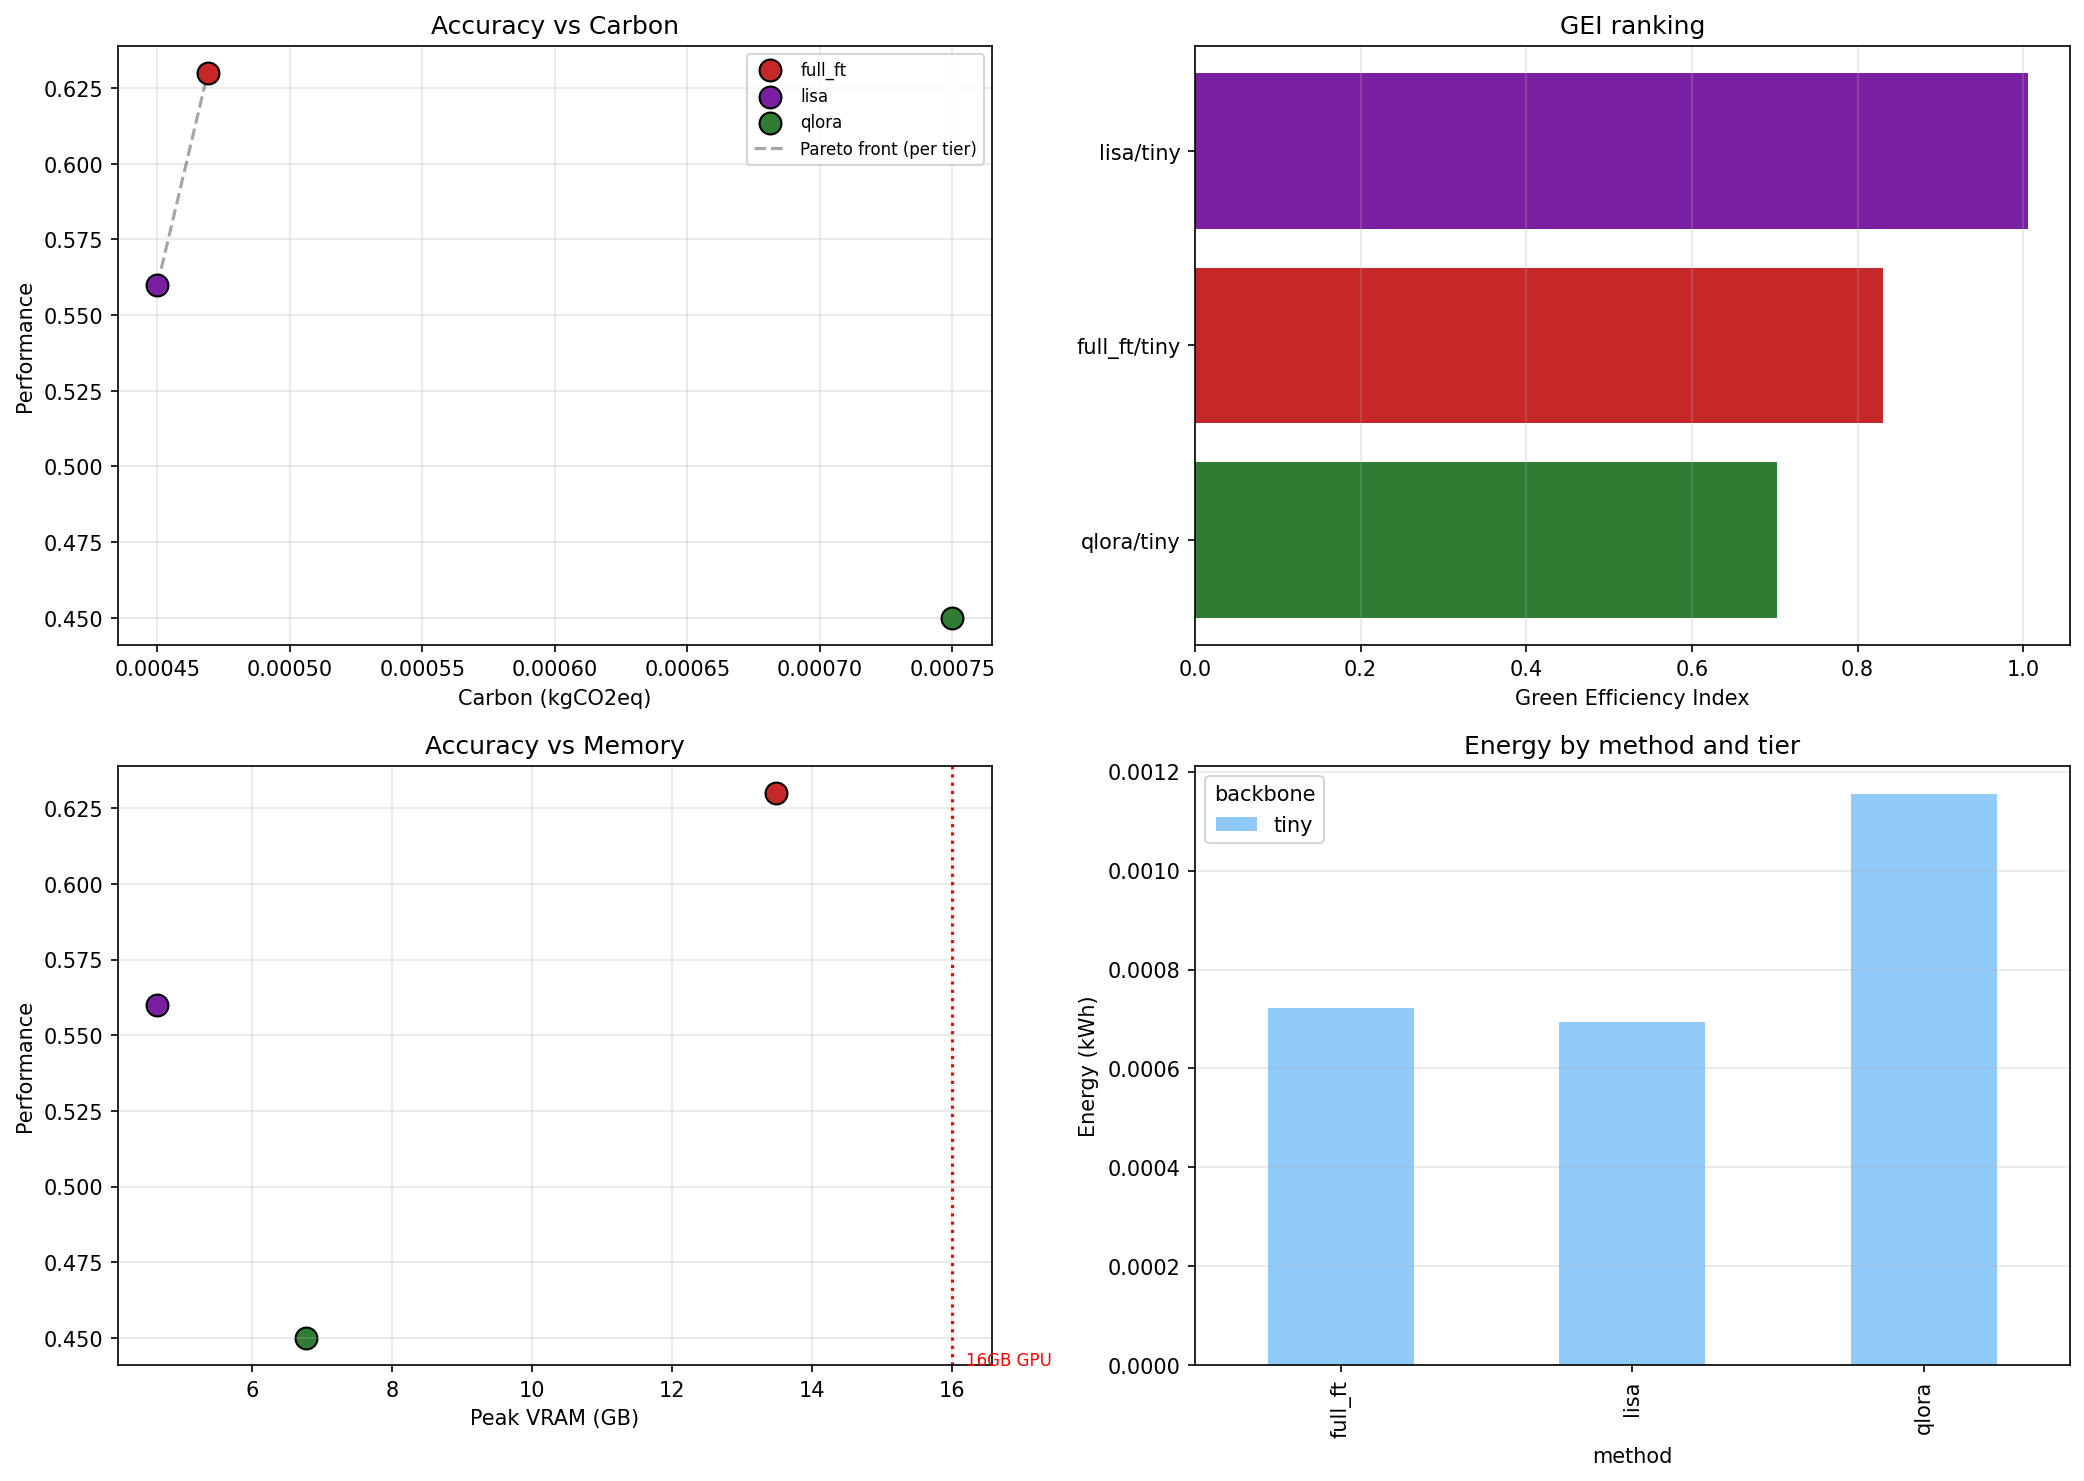

In [15]:
# ==================== CELL 15: Plots ====================
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

gei = pd.read_csv(RESULTS_DIR / 'aggregated_gei.csv')
pareto = pd.read_csv(RESULTS_DIR / 'pareto_fronts.csv')
MCOLORS = {'full_ft': '#c62828', 'lora': '#1565c0', 'qlora': '#2e7d32',
           'lora_fa': '#ef6c00', 'lisa': '#7b1fa2'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
for m, blk in gei.groupby('method'):
    ax.scatter(blk['carbon_kgco2eq_mean'], blk['accuracy_mean'], s=110,
               label=m, color=MCOLORS.get(m, 'gray'), edgecolor='k', zorder=3)
for lbl, pf in pareto.groupby('front_label'):
    pf = pf.sort_values('carbon_kgco2eq_mean')
    ax.plot(pf['carbon_kgco2eq_mean'], pf['accuracy_mean'], '--', color='k', alpha=.35)
ax.plot([], [], '--', color='k', alpha=.35, label='Pareto front (per tier)')
ax.set_xlabel('Carbon (kgCO2eq)'); ax.set_ylabel('Performance'); ax.set_title('Accuracy vs Carbon')
ax.legend(fontsize=8); ax.grid(alpha=.3)

ax = axes[0, 1]
o = gei.sort_values('gei', ascending=True)
ax.barh([f'{r.method}/{r.backbone}' for r in o.itertuples()], o['gei'],
        color=[MCOLORS.get(m, 'gray') for m in o['method']])
ax.set_xlabel('Green Efficiency Index'); ax.set_title('GEI ranking'); ax.grid(alpha=.3, axis='x')

ax = axes[1, 0]
for m, blk in gei.groupby('method'):
    ax.scatter(blk['peak_mem_gb_mean'], blk['accuracy_mean'], s=110,
               label=m, color=MCOLORS.get(m, 'gray'), edgecolor='k')
ax.axvline(16, ls=':', color='r'); ax.text(16.2, ax.get_ylim()[0], '16GB GPU', color='r', fontsize=8)
ax.set_xlabel('Peak VRAM (GB)'); ax.set_ylabel('Performance'); ax.set_title('Accuracy vs Memory')
ax.grid(alpha=.3)

ax = axes[1, 1]
piv = gei.pivot_table(index='method', columns='backbone', values='energy_kwh_mean')
piv.plot(kind='bar', ax=ax, color=['#90caf9', '#64b5f6', '#1e88e5', '#0d47a1'][:piv.shape[1]])
ax.set_ylabel('Energy (kWh)'); ax.set_title('Energy by method and tier'); ax.grid(alpha=.3, axis='y')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'benchmark_overview.png', dpi=150, bbox_inches='tight')
print('Saved', FIGURES_DIR / 'benchmark_overview.png')

from IPython.display import Image, display as _d
_d(Image(str(FIGURES_DIR / 'benchmark_overview.png')))

In [16]:
# ==================== CELL 16: Export bundle ====================
import shutil

staging = ROOT / 'export_bundle'
if staging.exists():
    shutil.rmtree(staging)
staging.mkdir(parents=True)

for src in [RAW_DIR, FIGURES_DIR, CONFIG_DIR,
            RESULTS_DIR / 'sweep_raw.csv', RESULTS_DIR / 'aggregated.csv',
            RESULTS_DIR / 'aggregated_scored.csv', RESULTS_DIR / 'aggregated_gei.csv',
            RESULTS_DIR / 'pareto_fronts.csv']:
    if src.is_dir():
        shutil.copytree(src, staging / src.name, dirs_exist_ok=True)
    elif src.exists():
        shutil.copy2(src, staging / src.name)

manifest = {
    'generated_at': time.strftime('%Y-%m-%d %H:%M:%S'),
    'run_mode': RUN_MODE, 'platform': PLATFORM, 'gpu': GPU_NAME,
    'backbones': BACKBONES, 'methods': METHODS, 'tasks': TASKS, 'seeds': SEEDS,
    'train_steps': TRAIN_STEPS, 'batch_size': BATCH_SIZE,
    'grid_carbon_kg_per_kwh': GRID_CARBON_KG_PER_KWH,
    'gei_weights': GEI_WEIGHTS,
    'n_raw_runs': len(list(RAW_DIR.glob('*.json'))),
}
json.dump(manifest, open(staging / 'manifest.json', 'w'), indent=2)

archive = shutil.make_archive(str(ROOT / 'sustainable_peft_benchmark_bundle'), 'zip', staging)
print('Bundle:', archive)
print('Size  :', round(Path(archive).stat().st_size / 1e6, 2), 'MB')
if IN_KAGGLE:
    shutil.copy2(archive, '/kaggle/working/')
    print('\nCopied to /kaggle/working -> download it from the Output panel on the right.')
elif IN_COLAB:
    from google.colab import files
    print('\nRun files.download(archive) in a new cell to download it.')

Bundle: /kaggle/working/peft_bench/sustainable_peft_benchmark_bundle.zip
Size  : 0.13 MB

Copied to /kaggle/working -> download it from the Output panel on the right.


## Troubleshooting

| Symptom | Fix |
|---|---|
| `ImportError` right after Cell 1 | Session -> Restart, then run Cell 1 again with `INSTALL = False` |
| `CUDA out of memory` on every run | Lower `BATCH_SIZE` to 2 and `MAX_SEQ_LEN` to 128 in Cell 2 |
| QLoRA rows all skipped | Your GPU is a P100. Switch Kaggle accelerator to **GPU T4 x2** |
| Dataset download fails on Kaggle | Notebook Settings -> Internet = **ON** |
| Energy is a flat number every run | NVML is missing, so a fixed TDP was used. Only real on a proper GPU runtime |
| Session died mid-sweep | Just re-run Cell 10. Finished runs are skipped automatically |
| `full_ft` rows say `oom` | Expected on medium/large tiers with 16 GB. It is a result, keep it |

## Kaggle vs Colab

| | Kaggle | Colab Free |
|---|---|---|
| GPU | T4 x2 or P100, 16 GB | T4, 16 GB |
| Session length | 12 h | ~90 min idle cutoff |
| Weekly quota | 30 h | vague, throttled |
| Files survive | Yes, in `/kaggle/working` | No, wiped on disconnect |
| Verdict | **Use this for the real sweep** | Fine for `smoke` only |
